## Task 1: Data Acquisition and Exploration


In [4]:
!pip install ucimlrepo

In [5]:
# Download and load the dataset 
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables) 


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [6]:
# Compute summary statistics (mean, median, standard deviation, etc.) for all features.
import pandas as pd

df_bc = X.copy()
df_bc['Diagnosis'] = y

summary_stats = df_bc.drop(columns=['Diagnosis']).describe().T
summary_stats['median'] = df_bc.drop(columns=['Diagnosis']).median()
summary_stats = summary_stats[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]
print(summary_stats)

                          mean      median         std         min  \
radius1              14.127292   13.370000    3.524049    6.981000   
texture1             19.289649   18.840000    4.301036    9.710000   
perimeter1           91.969033   86.240000   24.298981   43.790000   
area1               654.889104  551.100000  351.914129  143.500000   
smoothness1           0.096360    0.095870    0.014064    0.052630   
compactness1          0.104341    0.092630    0.052813    0.019380   
concavity1            0.088799    0.061540    0.079720    0.000000   
concave_points1       0.048919    0.033500    0.038803    0.000000   
symmetry1             0.181162    0.179200    0.027414    0.106000   
fractal_dimension1    0.062798    0.061540    0.007060    0.049960   
radius2               0.405172    0.324200    0.277313    0.111500   
texture2              1.216853    1.108000    0.551648    0.360200   
perimeter2            2.866059    2.287000    2.021855    0.757000   
area2               

In [7]:
#  Check for missing values, duplicates, or outliers. Handle them 
print("Missing values per column:")
print(df_bc.isnull().sum().sum())

print("\nDuplicate rows:", df_bc.duplicated().sum())

Q1 = df_bc.drop(columns=['Diagnosis']).quantile(0.25)
Q3 = df_bc.drop(columns=['Diagnosis']).quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((df_bc.drop(columns=['Diagnosis']) < (Q1 - 1.5*IQR)) | (df_bc.drop(columns=['Diagnosis']) > (Q3 + 1.5*IQR))).sum()
print("\nOutlier counts per feature:")
print(outlier_counts.sort_values(ascending=False))

df_bc_handled = df_bc.drop_duplicates().copy()

for col in df_bc_handled.drop(columns=['Diagnosis']).columns:
    q1 = df_bc_handled[col].quantile(0.25)
    q3 = df_bc_handled[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    df_bc_handled[col] = df_bc_handled[col].clip(lower, upper)

print("\nShape after handling:", df_bc_handled.shape)

Missing values per column:
0

Duplicate rows: 0

Outlier counts per feature:
area2                 65
radius2               38
perimeter2            38
area3                 35
smoothness2           30
compactness2          28
fractal_dimension2    28
symmetry2             27
area1                 25
fractal_dimension3    24
symmetry3             23
concavity2            22
texture2              20
concave_points2       19
concavity1            18
radius3               17
compactness3          16
compactness1          16
perimeter3            15
fractal_dimension1    15
symmetry1             15
radius1               14
perimeter1            13
concavity3            12
concave_points1       10
texture1               7
smoothness3            7
smoothness1            6
texture3               5
concave_points3        0
dtype: int64

Shape after handling: (569, 31)


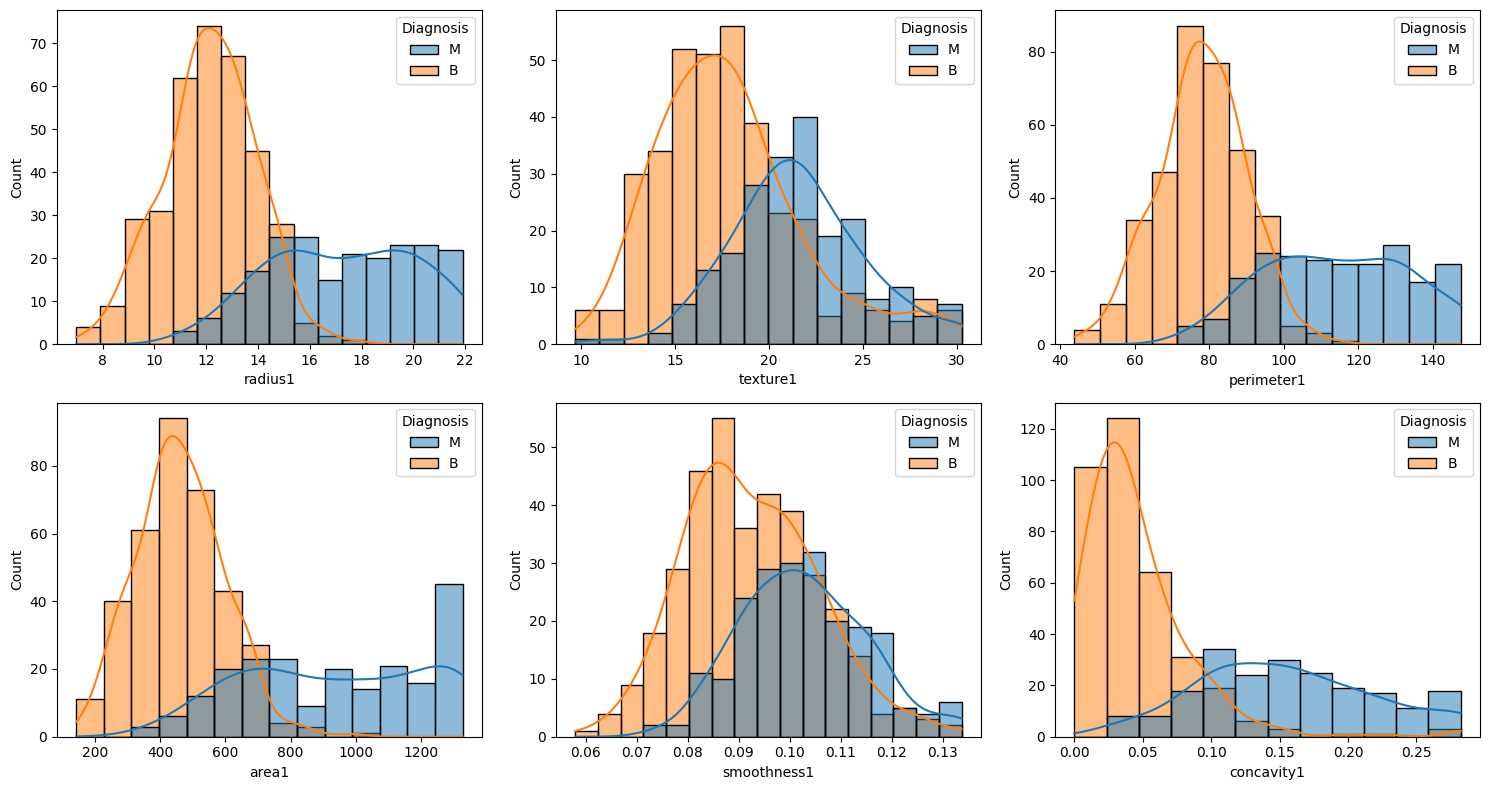

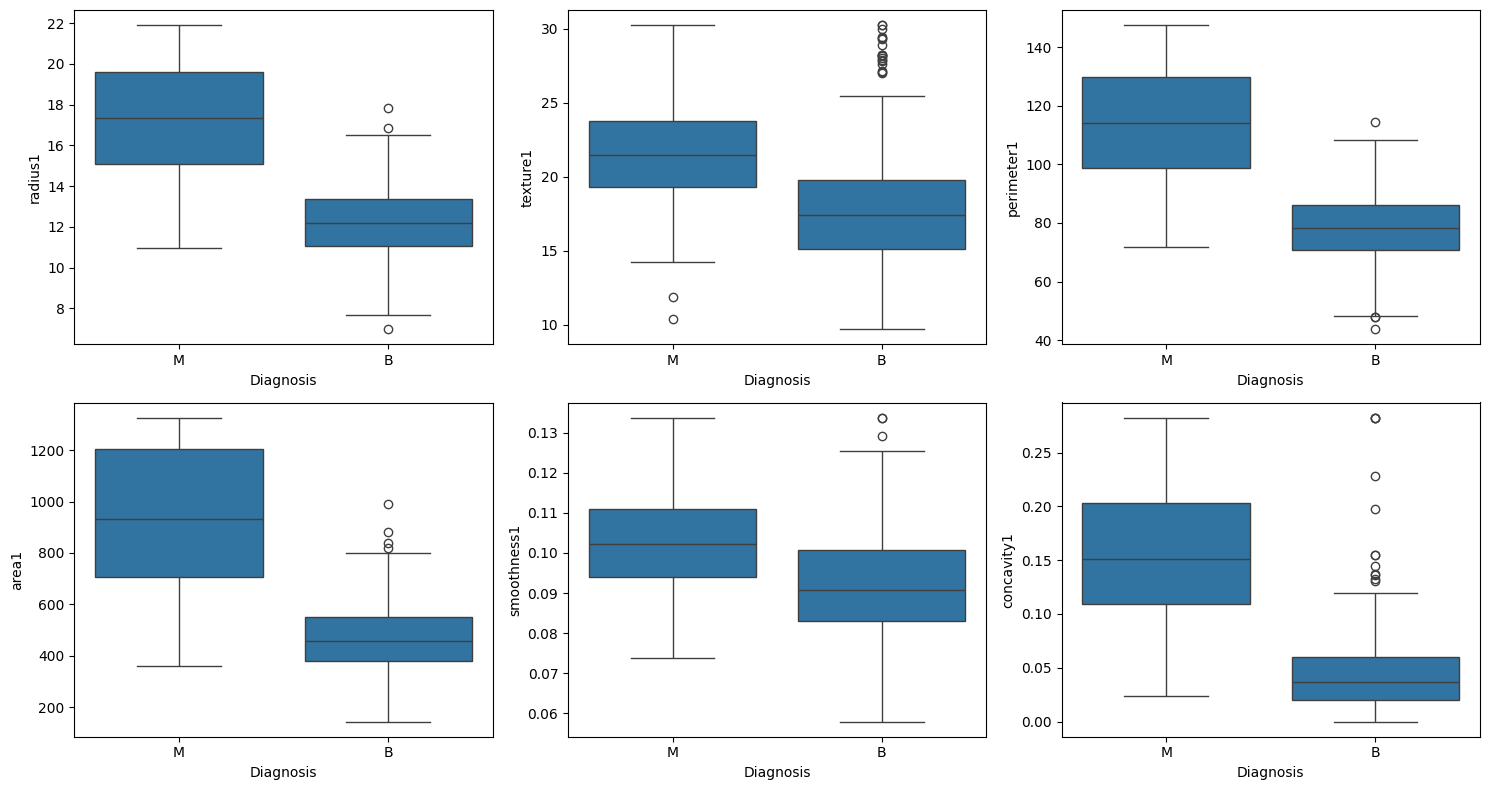

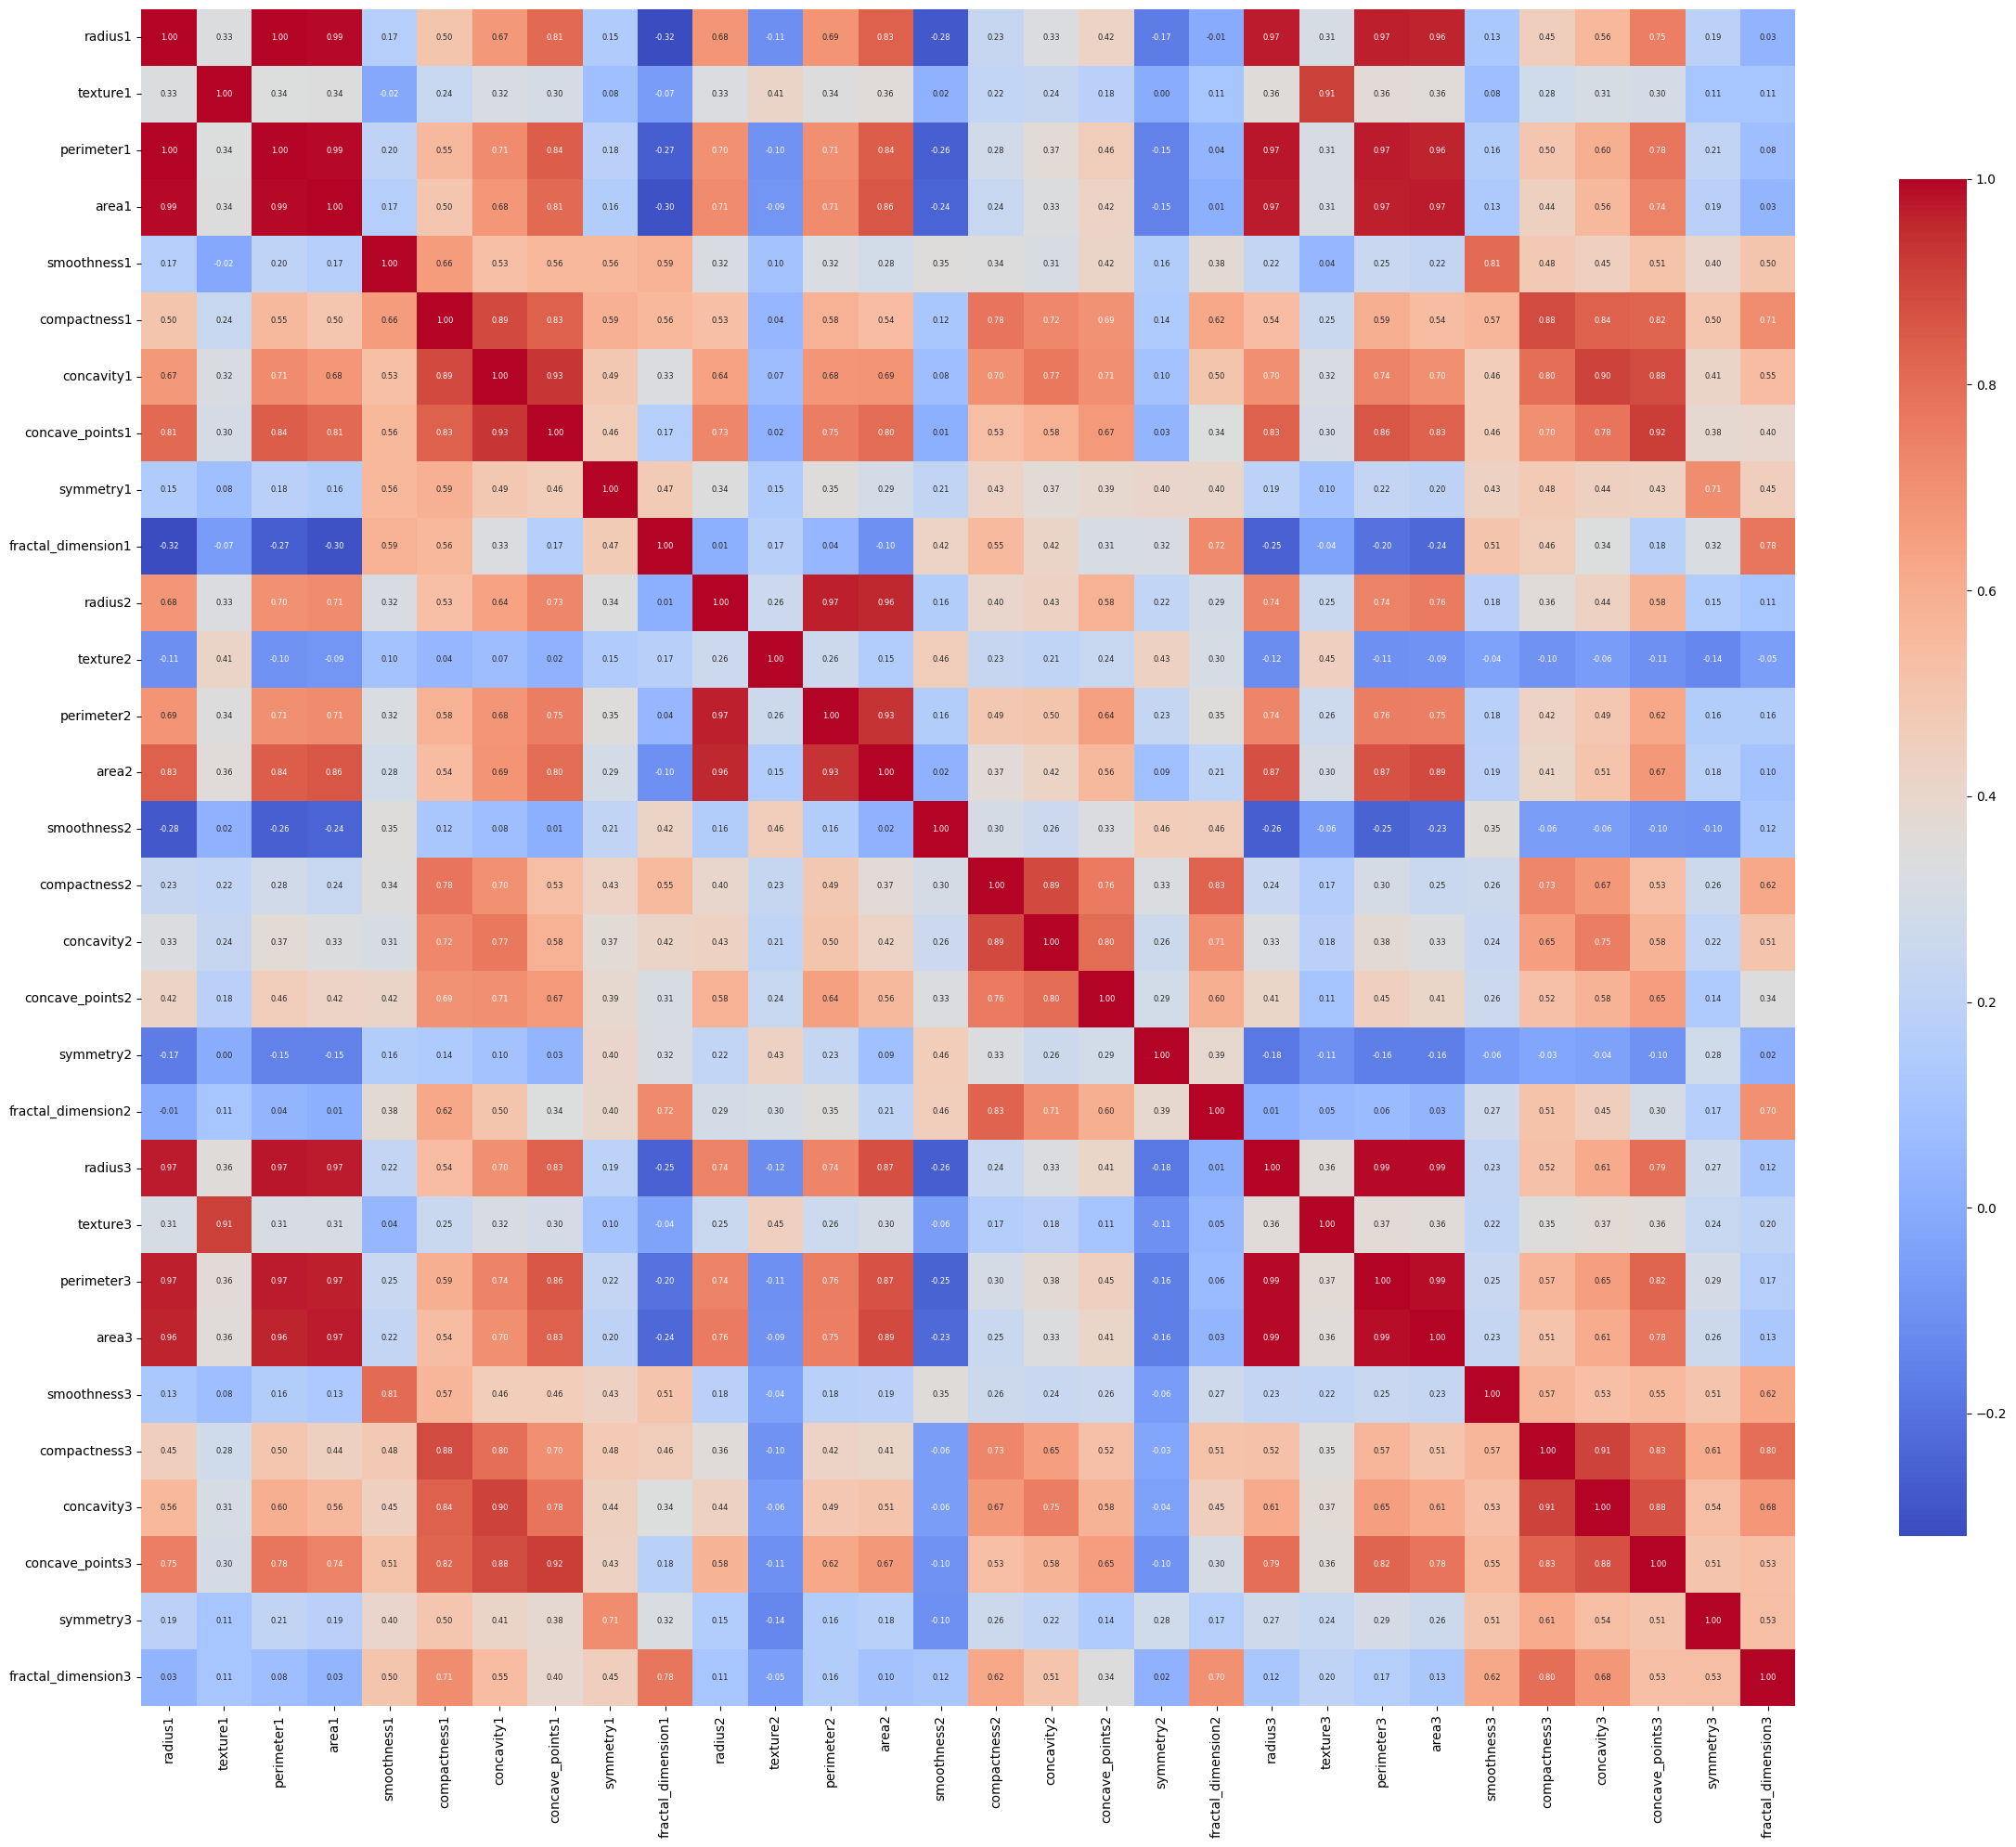

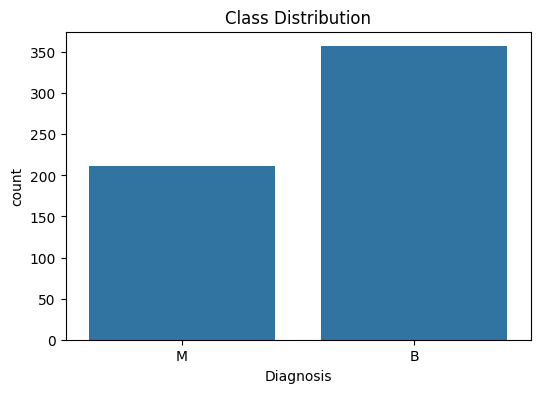

Diagnosis
B    357
M    212
Name: count, dtype: int64
Diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64


In [8]:
# Visualize the data: Create histograms or box plots for key features, a correlation heatmap, and class distribution.
import matplotlib.pyplot as plt
import seaborn as sns

key_features = ['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'concavity1']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.histplot(data=df_bc_handled, x=col, hue='Diagnosis', kde=True, ax=axes[i])
plt.tight_layout()
plt.savefig('bc_histograms.png')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(key_features):
    sns.boxplot(x='Diagnosis', y=col, data=df_bc_handled, ax=axes[i])
plt.tight_layout()
plt.savefig('bc_boxplots.png')
plt.show()

plt.figure(figsize=(24, 20))
corr = df_bc_handled.drop(columns=['Diagnosis']).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', annot_kws={'size': 6}, cbar_kws={'shrink': 0.8})
plt.tight_layout()
plt.savefig('bc_correlation_annotated.png')
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='Diagnosis', data=df_bc_handled)
plt.title('Class Distribution')
plt.savefig('bc_class_distribution.png')
plt.show()

print(df_bc_handled['Diagnosis'].value_counts())
print(df_bc_handled['Diagnosis'].value_counts(normalize=True) * 100)

### Discuss any imbalances in the class distribution and potential implications for model training.
The dataset shows a moderate class imbalance: 212 malignant (37.3%) vs 357 benign
(62.7%) cases — roughly a 1:1.7 ratio.

This is not severe imbalance (unlike, say, 1:20 in rare disease screening), but it
still has implications for model training:

1. A model could achieve ~63% accuracy by simply predicting "Benign" for every
   sample, without learning anything useful - so accuracy alone is a poor metric
   here.

2. Since this is medical diagnosis, missing a malignant case (false negative) is
   far more dangerous than a false alarm (false positive). A model trained
   without accounting for this could be biased toward predicting the majority
   class (Benign) more often, increasing the risk of missing actual cancer cases.

3. This makes Recall (sensitivity) for the malignant class especially important
   to monitor - a high accuracy but low recall for "M" would mean the model is
   unreliable for its actual clinical purpose.

4. Using stratified train/test splitting (as required in Task 2) is essential
   here, to ensure both classes are proportionally represented in training and
   test sets. Techniques like class_weight='balanced' in logistic regression, or
   oversampling (SMOTE), could also help the model pay more attention to the
   minority (malignant) class during training.

## Task 2 Data Preprocessing

In [9]:
df_bc_handled['Diagnosis'] = df_bc_handled['Diagnosis'].map({'M': 1, 'B': 0})

print(df_bc_handled['Diagnosis'].value_counts())
print(df_bc_handled['Diagnosis'].dtype)

Diagnosis
0    357
1    212
Name: count, dtype: int64
int64


In [10]:
# Train/test split (stratified)
from sklearn.model_selection import train_test_split

X_bc = df_bc_handled.drop(columns=['Diagnosis'])
y_bc = df_bc_handled['Diagnosis']

X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc, y_bc, test_size=0.2, random_state=42, stratify=y_bc
)

print(X_train_bc.shape, X_test_bc.shape)
print(y_train_bc.value_counts(normalize=True))
print(y_test_bc.value_counts(normalize=True))

(455, 30) (114, 30)
Diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64
Diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [11]:
# Standardization
from sklearn.preprocessing import StandardScaler

scaler_bc = StandardScaler()
X_train_bc_scaled = scaler_bc.fit_transform(X_train_bc)
X_test_bc_scaled = scaler_bc.transform(X_test_bc)

print(X_train_bc_scaled.mean(axis=0)[:5])
print(X_train_bc_scaled.std(axis=0)[:5])

[-8.62801893e-16 -3.12326477e-16 -1.77635684e-16 -5.85612145e-17
 -7.69103950e-16]
[1. 1. 1. 1. 1.]


## Task 3: Model Training and Basic Evaluation

In [12]:
# Train logistic regression model
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_bc_scaled, y_train_bc)

y_pred_bc = log_reg.predict(X_test_bc_scaled)
y_pred_proba_bc = log_reg.predict_proba(X_test_bc_scaled)[:, 1]

print("Model trained successfully")
print("Coefficients shape:", log_reg.coef_.shape)

Model trained successfully
Coefficients shape: (1, 30)


/Users/pankurajasaivardhan/Documents/AIH/aih/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/AIH/aih/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/AIH/aih/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pankurajasaivardhan/Documents/AIH/aih/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/pankurajasaivardhan/Documents/AIH/aih/lib/python3.10/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning:

Accuracy: 0.9649

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



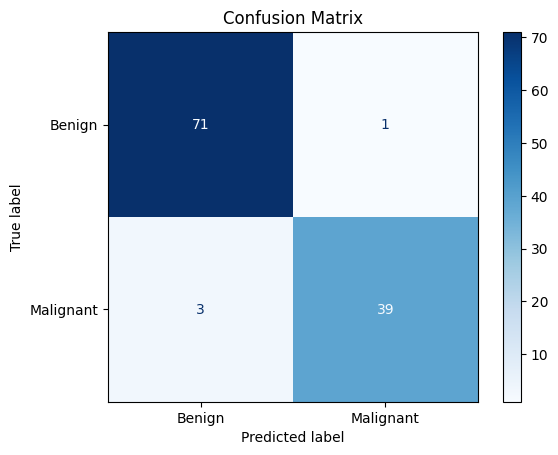

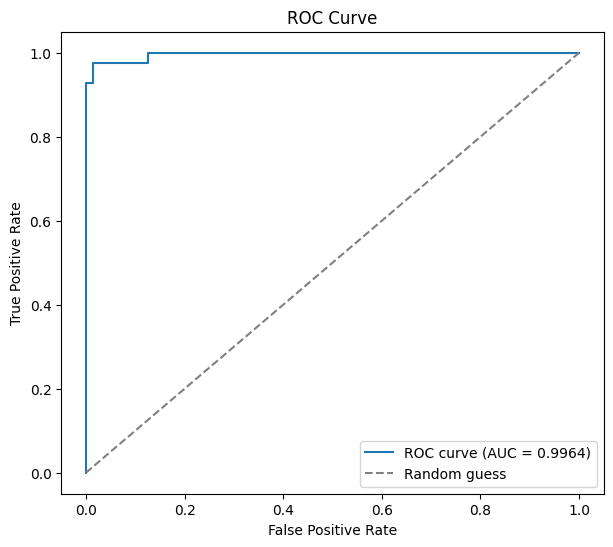


AUC Score: 0.9964


In [13]:
# Evaluation (accuracy, precision/recall/F1, confusion matrix, ROC-AUC)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, roc_auc_score
)
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test_bc, y_pred_bc)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_bc, y_pred_bc, target_names=['Benign (0)', 'Malignant (1)']))

cm = confusion_matrix(y_test_bc, y_pred_bc)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('bc_confusion_matrix.png')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test_bc, y_pred_proba_bc)
auc_score = roc_auc_score(y_test_bc, y_pred_proba_bc)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig('bc_roc_curve.png')
plt.show()

print(f"\nAUC Score: {auc_score:.4f}")

**Interpretation of Results:**

The logistic regression model performs very well on this dataset, achieving
96.49% accuracy and an AUC of 0.9964 - close to a perfect separation between
benign and malignant cases.

Looking closer at the confusion matrix:
- 71 Benign cases correctly identified, only 1 false positive (predicted
  Malignant when actually Benign).
- 39 Malignant cases correctly identified, but 3 false negatives (predicted
  Benign when actually Malignant).

In a medical diagnosis context, these two error types are not equally
serious:

- A **false positive** (predicting cancer when there isn't one) leads to
  unnecessary anxiety and further testing (like a biopsy), but the patient is
  eventually cleared - costly and stressful, but not life-threatening.
- A **false negative** (predicting benign when the tumor is actually
  malignant) is far more dangerous - it means a real cancer case goes
  undetected and untreated, potentially delaying critical treatment.

This model's recall for the Malignant class is 0.93 (93%), meaning it
correctly catches 93% of actual cancer cases but misses about 7% (3 out of
42 cases in this test set). While the overall accuracy looks excellent, this
7% miss rate is the number that matters most clinically - in a real deployment,
every missed malignant case is a patient whose cancer wasn't flagged in time.

The high precision for Malignant (0.97) shows that when the model does
predict cancer, it's usually right, keeping false alarms low. But given the
cost asymmetry in healthcare, it would be worth prioritizing recall over
precision for the Malignant class here - for example, by adjusting the
classification threshold (instead of the default 0.5) to catch more true
positives, even at the cost of a few more false positives. This model would
likely be used as a decision-support tool alongside a doctor's judgment, not
as a sole diagnostic authority, precisely because a 93% recall, while strong,
is not yet safe enough to rely on unsupervised for a decision this critical.